In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [5]:
dataset=pd.read_csv("archive.zip")

In [6]:
dataset

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [9]:
dataset.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [7]:
dataset.shape

(13320, 9)

In [8]:
dataset.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [13]:
dataset.duplicated().sum()

np.int64(529)

In [15]:
dataset.drop(columns=["area_type","availability","balcony"],inplace=True)

In [16]:
dataset.head()

,location,size,society,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,Coomee,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,120.00
2,Uttarahalli,3 BHK,NaN,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,95.00
4,Kothanur,2 BHK,NaN,1200,2.0,51.00


In [23]:
dataset['society'].replace('NaN','unknown',inplace=True)

In [24]:
dataset.head()

,location,size,society,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,Coomee,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,120.00
2,Uttarahalli,3 BHK,unknown,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,95.00
4,Kothanur,2 BHK,unknown,1200,2.0,51.00


In [31]:
median_bath=dataset['bath'].median()


In [32]:
dataset['bath'].fillna(median_bath,inplace=True)

C:\Users\krishnam naidu\AppData\Local\Temp\ipykernel_12744\1317774805.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['bath'].fillna(median_bath,inplace=True)


In [34]:
mode_size=dataset['size'].mode()

In [40]:
dataset['size'].fillna(mode_size[0],inplace=True)

In [41]:
dataset.isna().sum()

location      1
size          0
society       0
total_sqft    0
bath          0
price         0
dtype: int64

In [42]:
dataset.dropna(inplace=True)

In [43]:
dataset.isna().sum()

location      0
size          0
society       0
total_sqft    0
bath          0
price         0
dtype: int64

In [51]:
dataset['total_sqft']

0        1056
1        2600
2        1440
3        1521
4        1200
         ... 
13315    3453
13316    3600
13317    1141
13318    4689
13319     550
Name: total_sqft, Length: 13319, dtype: object

In [48]:
dataset['BHK']=dataset['size'].apply(lambda x:int(x.split()[0]))


In [50]:
dataset.drop(columns='size',inplace=True)

In [59]:
def convert_sqft(x):
    try:
        if '-' in x:
            a,b=x.split('-')
            return (float(a)+float(b))/2
            return float(x)
    except:
        return none
    

In [60]:
dataset['total_sqft']=dataset['total_sqft'].apply(convert_sqft)


In [71]:
dataset.dropna(inplace=True)

In [72]:
dataset['location']=dataset['location'].astype('category').cat.codes

In [73]:
dataset['society']=dataset['society'].astype('category').cat.codes

In [74]:
X=dataset.drop('price',axis=1)

In [75]:
Y=dataset['price']

In [76]:
Y

30       186.000
56       192.000
81       224.500
122      477.000
137       54.005
          ...   
12990    122.000
13059     72.760
13240     52.570
13265     59.135
13299    154.500
Name: price, Length: 201, dtype: float64

In [77]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)

In [78]:
from sklearn.linear_model import LinearRegression

In [79]:
model=LinearRegression()

In [80]:
model.fit(x_train,y_train)

LinearRegression()

In [81]:
y_pred=model.predict(x_test)

In [82]:
compare=pd.DataFrame()
compare["Actual Charges"]=y_test
compare["Predicted Charges"]=y_pred
print(compare)

       Actual Charges  Predicted Charges
4884           32.670          51.790013
3356          125.500         166.217597
9853           40.550          36.431305
7398          237.500         243.850027
5179           32.640          10.705735
5382           34.735          22.286034
1484           42.720           4.492094
2575          145.500         174.506301
6386           34.555          59.115778
9699          246.000         196.251652
7797          118.000         129.889093
10870          56.725          46.763901
8703           42.300          98.016318
2500          260.500         230.799791
7747           38.535          20.152887
3544           93.865          94.178350
11042          76.160          75.802135
11827          55.195          71.637485
7921           85.125         104.666640
3468           49.475          28.084024
8023          393.500         351.457000
5498           66.165         113.740432
11285          40.985          70.817221
4497          19

In [83]:
from sklearn.metrics import r2_score
r=r2_score(y_test,y_pred)
print(r)

0.8816856329297736


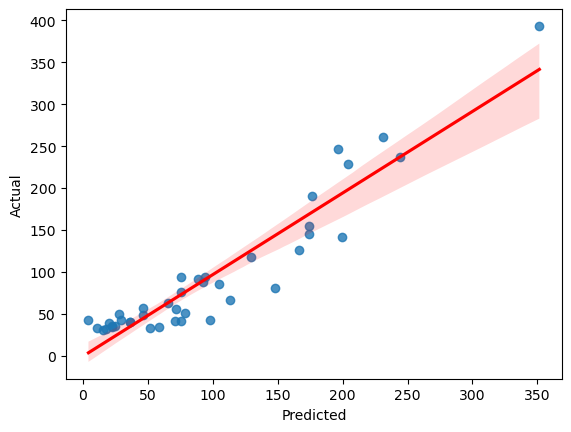

In [84]:
sb.regplot(x=y_pred,y=y_test,line_kws={"color":"red"})
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()